#  Cat vs. Dog Image Classification with Augmentation

# Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [21]:
from sklearn.model_selection import train_test_split

In [89]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, Flatten, Dropout, BatchNormalization
from keras.layers import Conv2D, MaxPooling2D, AveragePooling2D

from keras.losses import binary_crossentropy
from keras.optimizers import Adam

In [23]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [24]:
import cv2

In [31]:
import kagglehub
import os
import random

# Image Load

```python

keras.utils.image_dataset_from_directory(
    directory,
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

```

In [26]:
# Download latest version
path = kagglehub.dataset_download("anthonytherrien/dog-vs-cat")

print("Path to dataset files:", path)

# find images folder
print("Top-level folders:", os.listdir(path))

Using Colab cache for faster access to the 'dog-vs-cat' dataset.
Path to dataset files: /kaggle/input/dog-vs-cat
Top-level folders: ['animals']


In [29]:
my_dir = '/kaggle/input/dog-vs-cat/animals'
categories = ['cat', 'dog']
print(my_dir)
print(categories)

/kaggle/input/dog-vs-cat/animals
['cat', 'dog']


In [52]:
data = []

for category in categories:
    label = 0 if category == "cat" else 1
    path = os.path.join(my_dir, category)

    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (256, 256))

        data.append((img, label))

## Data Shuffle

In [59]:
random.shuffle(data)

In [36]:
type(data[0][0])

numpy.ndarray

# Image, Label Separate

In [45]:
x = []
y = []

for features, labels in data:
    x.append(features)
    y.append(labels)
print(len(x))
print(len(y))


1000
1000


In [44]:
type(x)

list

## Convert to Numpy Array

In [62]:
X = np.array(x)
y = np.array(y)

X.shape, y.shape

((1000, 256, 256, 3), (1000,))

## Visualize 12 sample images

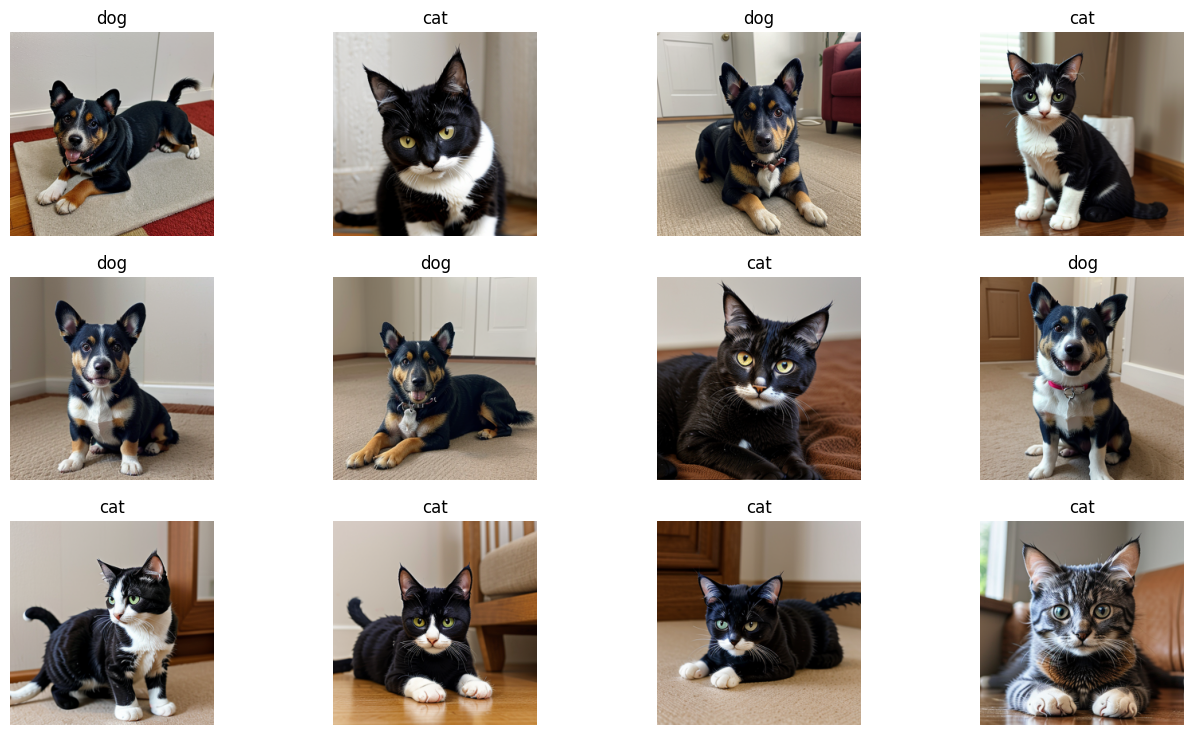

In [60]:
plt.figure(figsize=(16, 9))

for i in range(12):
    img, label = data[i]      # unpack
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert for matplotlib

    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(categories[label])
    plt.axis("off")

plt.show()

# Normalize Image

In [63]:
X = X / 255.0
X.shape

(1000, 256, 256, 3)

# Train Test Split

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
X_train.shape, X_test.shape

((800, 256, 256, 3), (200, 256, 256, 3))

# Custom Model Without `Augmentation`

In [90]:
def lenet5() -> Sequential:
  model = Sequential()

  # Input Layer
  model.add(Input(shape=(256, 256, 3)))

  # Convolution Layer 1
  model.add(Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='valid'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))

  # Convolution Layer 2
  model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='valid'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))

  # Convolution Layer 3
  model.add(Conv2D(filters=128, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='valid'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))

  # Flatten Layer
  model.add(Flatten())

  # Full connected layer
  model.add(Dense(units=256, activation='relu'))
  model.add(Dropout(0.3))
  model.add(Dense(units=128, activation='relu'))
  model.add(Dropout(0.2))
  model.add(Dense(units=64, activation='relu'))
  model.add(Dropout(0.1))
  model.add(Dense(units=1, activation='sigmoid'))

  return model

In [91]:
model = lenet5()
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │    29,491,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,626,817 (113.02 MB)

 Trainable params: 29,626,369 (113.02 MB)

 Non-trainable params: 448 (1.75 KB)

# Model Training

In [92]:
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss=tf.keras.losses.binary_crossentropy,
    metrics=['accuracy']
)

In [93]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 204ms/step - accuracy: 0.5483 - loss: 41.5216 - val_accuracy: 0.4550 - val_loss: 92.6740
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.6243 - loss: 5.0956 - val_accuracy: 0.5700 - val_loss: 1.6327
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.5675 - loss: 0.8167 - val_accuracy: 0.4600 - val_loss: 0.7488
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.5999 - loss: 0.6763 - val_accuracy: 0.4550 - val_loss: 0.7077
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.5814 - loss: 0.6198 - val_accuracy: 0.5600 - val_loss: 0.6841
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.6990 - loss: 0.5986 - val_accuracy: 0.5100 - val_loss: 0.6903
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.7354 - loss: 0.5746 - val_accuracy: 0.7000 - val_loss: 0.5902
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.7802 - loss: 0.4847 - val_accuracy: 0.5800

# Accuracy Plot

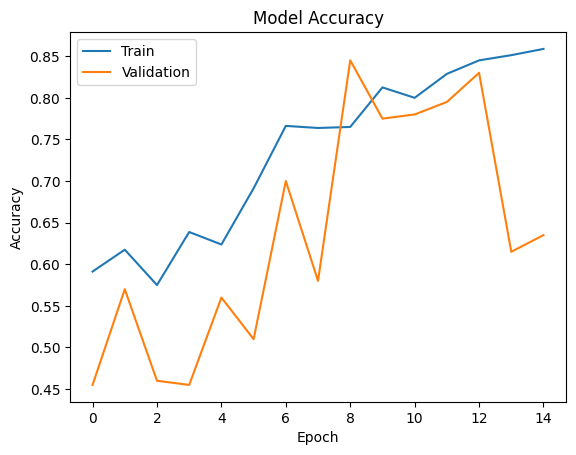

In [94]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Loss Plot

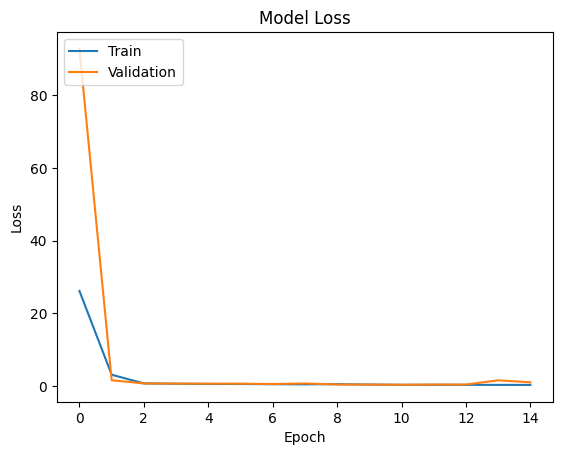

In [95]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# With Augmentation

## Data Generator

In [96]:
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [97]:
train_generator = train_datagen.flow_from_directory(
    my_dir,
    target_size=(256, 256),
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    my_dir,
    target_size=(256, 256),
    batch_size=batch_size,
    class_mode='binary'
)

Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


## Model Training

In [99]:
aug_model = lenet5()
aug_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │    29,491,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,626,817 (113.02 MB)

 Trainable params: 29,626,369 (113.02 MB)

 Non-trainable params: 448 (1.75 KB)

In [100]:
aug_model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss=tf.keras.losses.binary_crossentropy,
    metrics=['accuracy']
)

In [104]:
aug_history = aug_model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.5134 - loss: 24.5294 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.4872 - loss: 0.7869 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.4648 - loss: 0.6960 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.5218 - loss: 0.7300 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.5096 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.4955 - loss: 0.6959 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.5059 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 8/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.5102 - loss: 0.6922 - val_accuracy: 0.5000 - val_loss

## Accuracy Plot

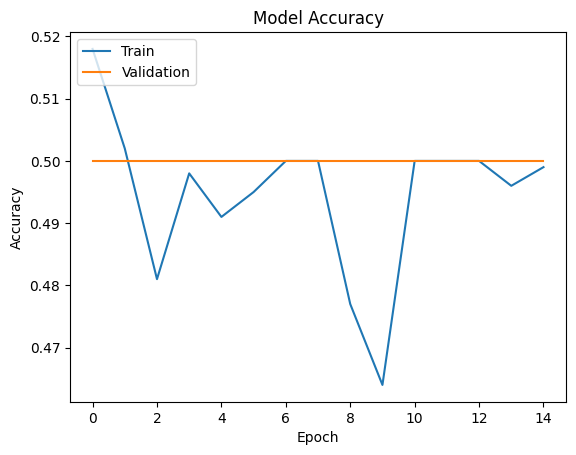

In [105]:
plt.plot(aug_history.history['accuracy'])
plt.plot(aug_history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')